# H-011 · Value (BIS REER) gate or tilt

**Decides:** `VALUE_MODE_STAR` — VALUE_MODE_STAR (candidate OVERLAY_STAR)

Sleeve: **core**. Primary metric: **net** `ann_sharpe`. `psr` = P(true SR > 0). STAR is manual.


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s3_fx_trend.report import (
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    require_star,
    save_star_stack,
    update_star_stack_key,
)
from backtest.s3_fx_trend.research import (
    RESEARCH_IS_END_S3,
    config_from_stack,
    register_hypothesis_arms,
    star_stack_path,
)
from backtest.s3_fx_trend.runner import run_s3_backtest
from backtest.s3_fx_trend.walkforward import embargo_bars_for_config, make_s3_folds
from data.ingestion.fx_fetcher import G10_V1_PAIRS
from data.processing.s3_fx_price_panel import price_panel_path, s3_data_dir
from strategies.s3_fx_trend.config import S3SimConfig

DATA_DIR = s3_data_dir(ROOT)
ARTIFACTS = os.path.join(ROOT, "04_backtest", "s3_fx_trend", "artifacts")
os.makedirs(ARTIFACTS, exist_ok=True)
TEARSHEET_DIR = ARTIFACTS
SLEEVE = "core"
HYP_ID = "H-011"
print("ROOT=", ROOT)
print("DATA_DIR=", DATA_DIR)
print("RESEARCH_IS_END_S3=", RESEARCH_IS_END_S3)


ROOT= c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
DATA_DIR= c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s3_fx_trend
RESEARCH_IS_END_S3= 2019-12-31 00:00:00


## 1. Load STAR stack


In [2]:
STACK_PATH = star_stack_path(SLEEVE)
stack = load_star_stack(STACK_PATH)
print("STAR stack path:", STACK_PATH)
print("Loaded keys with values:", {k: v for k, v in stack.items() if v is not None})
base_cfg = config_from_stack(stack)
print(base_cfg)


STAR stack path: C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s3_fx_trend\artifacts\s3_core_star_stack.json
Loaded keys with values: {'PAIR_VT_STAR': 'pair_vt', 'BOOK_VT_STAR': 'pair_plus_book_vt', 'CONVICTION_SCALING_STAR': 'sign_only', 'CARRY_MODE_STAR': 'tilt', 'SPIKE_MODE_STAR': 'both', 'CORR_CONFLICT_MODE_STAR': 'off', 'HORIZON_STAR': '3M', 'FAMILY_STAR': 'tsmom'}
S3SimConfig(pairs=('EURUSD', 'USDJPY', 'GBPUSD', 'USDCHF', 'USDCAD', 'AUDUSD', 'NZDUSD'), bar='1d', day_boundary_tz='America/New_York', day_boundary_hour=17, signal_family='tsmom', tsmom_lookbacks=(21, 63, 252), tsmom_blend='single_3m', donchian_n=55, donchian_hl_source='daily_ny_close', pair_vt=True, book_vt=True, vt_target_ann_vol=0.1, conviction_scaling='sign', weak_signal_flat_z=0.0, rebalance_band=0.0, carry_mode='tilt', carry_refresh='weekly', value_mode='off', value_refresh='monthly', carry_agree_scale=1.25, carry_disagree_scale=0.75, value_agree_scale=1.25, value_disagre

## 2. Data load (research panels)


In [3]:
def _read_parquet(path: str) -> pd.DataFrame:
    if not os.path.isfile(path):
        warnings.warn(f"missing panel: {path}")
        return pd.DataFrame()
    df = pd.read_parquet(path)
    if df.empty:
        warnings.warn(f"empty panel: {path}")
        return df
    if "date" in df.columns:
        df = df.copy()
        df["date"] = pd.to_datetime(df["date"])
    return df

price_path = price_panel_path("1d", data_dir=DATA_DIR)
panel = _read_parquet(price_path)
rates = _read_parquet(os.path.join(DATA_DIR, "g10_policy_rates.parquet"))
reer = _read_parquet(os.path.join(DATA_DIR, "bis_reer_monthly.parquet"))

if not panel.empty:
    is_mask = panel["date"] <= pd.Timestamp(RESEARCH_IS_END_S3)
    panel_is = panel.loc[is_mask].copy()
    panel_oos = panel.loc[~is_mask].copy()
else:
    panel_is = panel.copy()
    panel_oos = panel.copy()

print("price rows:", len(panel), "IS:", len(panel_is), "OOS:", len(panel_oos))
print("rates rows:", len(rates), "reer rows:", len(reer))

s1_weekly = None
s2_daily = None
for cand in (
    os.path.join(ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet"),
    os.path.join(ROOT, "04_backtest", "s1_equities", "artifacts", "s1_period_returns.parquet"),
):
    if os.path.isfile(cand):
        s1 = pd.read_parquet(cand)
        # best-effort: first numeric column as weekly series
        if "date" in s1.columns:
            s1 = s1.set_index(pd.to_datetime(s1["date"]))
        num = s1.select_dtypes(include=[np.number])
        if not num.empty:
            s1_weekly = num.iloc[:, 0]
        break


price rows: 39337 IS: 27096 OOS: 12241
rates rows: 7207 reer rows: 235


## 3. Arms (pre-register)


In [4]:
configs = {
    "off": config_from_stack(stack, hyp_overrides={"value_mode": "off"}),
    "gate": config_from_stack(stack, hyp_overrides={"value_mode": "gate", "value_refresh": "monthly"}),
    "tilt": config_from_stack(stack, hyp_overrides={"value_mode": "tilt", "value_refresh": "monthly"}),
}
register_hypothesis_arms(HYP_ID, list(configs.keys()), sleeve=SLEEVE, overwrite=True)
print("registered", list(configs.keys()))
print("BIS REER PIT: availability_date = first day of M+2 — see s3_algorithm_notes.md")


registered ['off', 'gate', 'tilt']
BIS REER PIT: availability_date = first day of M+2 — see s3_algorithm_notes.md


## 4. Fold-val + boxplots

Boxplots use **net** Sharpe and max DD (shown inline). Full-IS is computed here; the locked metrics table is shown in §5.


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,2007-01-01,2009-10-30,989,2009-10-31,2009-11-04,2009-11-05,2012-08-12,994
1,2,2007-01-01,2012-08-06,1983,2012-08-07,2012-08-12,2012-08-13,2016-04-14,994
2,3,2007-01-01,2016-04-07,2977,2016-04-10,2016-04-14,2016-04-17,2019-12-30,995


,arm,fold_id,ann_sharpe,ann_sharpe_gross,max_drawdown,calmar,corr_to_s1,corr_to_s2,psr,dsr_local,dsr_stack,skew,excess_kurtosis,cost_bps_per_year,n_days,n_entries,n_trials_local,n_trials_stack
0,off,1,0.556477,0.638880,-0.128508,0.350737,NaN,NaN,1.000000e+00,1.000000e+00,1.000000e+00,0.005894,0.192612,176.450681,992,330,3,33
1,off,2,0.057562,0.240812,-0.143456,0.008135,0.261396,NaN,9.646920e-01,8.307349e-01,3.822182e-01,-0.054214,-0.260435,236.528879,992,373,3,33
2,off,3,0.017031,0.136725,-0.116755,-0.019968,-0.017062,NaN,7.041756e-01,3.758413e-01,5.749973e-02,0.016126,-0.317721,283.188190,993,427,3,33
3,gate,1,-0.235463,-0.006571,-0.186721,-0.117860,NaN,NaN,9.453549e-14,1.110223e-16,0.000000e+00,-0.085533,0.557656,176.450681,992,330,3,33
4,gate,2,-0.105653,0.066827,-0.163728,-0.074864,-0.145577,NaN,4.718951e-04,1.628926e-05,3.204865e-08,0.058820,-0.054339,236.528879,992,373,3,33
5,gate,3,0.094024,0.360277,-0.112295,0.038634,0.001949,NaN,9.983898e-01,9.820270e-01,8.008142e-01,-0.066634,-0.061885,283.188190,993,427,3,33
6,tilt,1,0.326230,0.451795,-0.140088,0.174959,NaN,NaN,1.000000e+00,1.000000e+00,1.000000e+00,0.016755,0.153543,176.450681,992,330,3,33
7,tilt,2,0.002749,0.191381,-0.150119,-0.025087,0.164928,NaN,5.344848e-01,2.217574e-01,2.138799e-02,0.014265,-0.299415,236.528879,992,373,3,33
8,tilt,3,-0.124256,0.046260,-0.149713,-0.097332,0.007839,NaN,4.663187e-05,9.729819e-07,8.906384e-10,-0.027396,-0.309277,283.188190,993,427,3,33


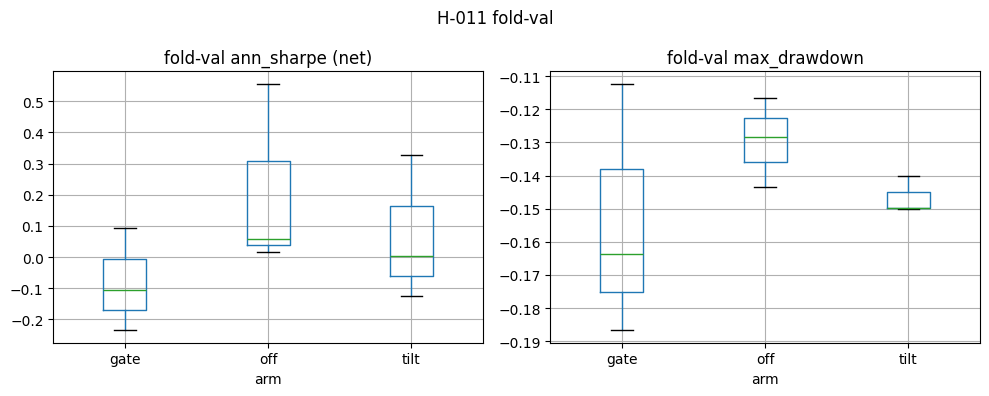

median_sharpe_hint (commentary only): off


In [5]:
FULL_IS_COLS = [
    "arm",
    "ann_sharpe",
    "ann_sharpe_gross",
    "max_drawdown",
    "corr_to_s1",
    "corr_to_s2",
    "calmar",
    "psr",
    "dsr_local",
    "dsr_stack",
    "skew",
    "excess_kurtosis",
    "cost_bps_per_year",
    "n_days",
    "n_entries",
]

fold_df = pd.DataFrame()
full_is_df = pd.DataFrame()
_reer = reer if "reer" in dir() else pd.DataFrame()

if panel_is.empty or "date" not in panel_is.columns:
    print("SKIP fold-val / full-IS: research IS price panel missing or empty.")
    print("Run 01_data/data_files/s3_fx_trend/s3_research_panels.ipynb first.")
else:
    is_dates = pd.DatetimeIndex(panel_is["date"].drop_duplicates().sort_values())
    try:
        folds = make_s3_folds(
            is_dates,
            n_folds=3,
            embargo_bars=embargo_bars_for_config(bar=getattr(base_cfg, "bar", "1d")),
        )
        display(fold_table(folds))
        fold_df = fold_val_metrics(
            panel_is,
            folds,
            configs,
            hyp_id=HYP_ID,
            sleeve=SLEEVE,
            s1_weekly=s1_weekly,
            s2_daily=s2_daily,
            rates_df=rates if not rates.empty else None,
            reer_df=_reer if not _reer.empty else None,
        )
        display(fold_df.head(20))

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        if not fold_df.empty and "ann_sharpe" in fold_df.columns:
            fold_df.boxplot(column="ann_sharpe", by="arm", ax=axes[0])
            axes[0].set_title("fold-val ann_sharpe (net)")
            axes[0].set_xlabel("arm")
        if not fold_df.empty and "max_drawdown" in fold_df.columns:
            fold_df.boxplot(column="max_drawdown", by="arm", ax=axes[1])
            axes[1].set_title("fold-val max_drawdown")
            axes[1].set_xlabel("arm")
        plt.suptitle(f"{HYP_ID} fold-val")
        plt.tight_layout()
        plt.show()

        full_is_df = full_is_metrics(
            panel_is,
            configs,
            hyp_id=HYP_ID,
            sleeve=SLEEVE,
            s1_weekly=s1_weekly,
            s2_daily=s2_daily,
            rates_df=rates if not rates.empty else None,
            reer_df=_reer if not _reer.empty else None,
        )
        hint = median_sharpe_hint(fold_df)
        print("median_sharpe_hint (commentary only):", hint)
    except Exception as exc:
        warnings.warn(f"fold-val / full-IS failed (panel may be too short): {exc!r}")


## 5. Full-IS metrics table

Locked columns: `ann_sharpe`, `ann_sharpe_gross`, `max_drawdown`, `corr_to_s1`, `corr_to_s2`, `calmar`, `psr`, `dsr_local`, `dsr_stack`, `skew`, `excess_kurtosis`, `cost_bps_per_year`, `n_days`, `n_entries`.


In [6]:
display(full_is_df[[c for c in FULL_IS_COLS if c in full_is_df.columns]]) if not full_is_df.empty else print('no full-IS yet')


,arm,ann_sharpe,ann_sharpe_gross,max_drawdown,corr_to_s1,corr_to_s2,calmar,psr,dsr_local,dsr_stack,skew,excess_kurtosis,cost_bps_per_year,n_days,n_entries
0,off,0.400537,0.526822,-0.167577,0.039485,NaN,0.190632,1.0,1.0,1.0,-0.018636,-0.113210,204.958945,3975,1406
1,gate,0.224204,0.418867,-0.242920,-0.028667,NaN,0.063268,1.0,1.0,1.0,-0.037520,0.214643,204.958945,3975,1406
2,tilt,0.310692,0.462431,-0.173361,0.044289,NaN,0.137459,1.0,1.0,1.0,-0.004045,-0.097407,204.958945,3975,1406


## 6. Freeze STAR (manual)


In [7]:
# MANUAL STAR freeze — edit the value, then run. Do not auto-assign from hint.
# STAR_KEY = "VALUE_MODE_STAR"
# STAR_VALUE = None  # e.g. "gate"

STAR_KEY = "VALUE_MODE_STAR"
STAR_VALUE = "off"  # <-- set manually after reviewing fold-val / full-IS

if STAR_VALUE is None:
    print(f"STAR_VALUE is None — leave unset until you decide. stack[{STAR_KEY!r}] stays as-is.")
else:
    update_star_stack_key(STACK_PATH, STAR_KEY, STAR_VALUE)
    stack = load_star_stack(STACK_PATH)
    require_star(STAR_KEY, stack.get(STAR_KEY))
    print("Froze", STAR_KEY, "=", stack.get(STAR_KEY))


Froze VALUE_MODE_STAR = off


## 7. Optional sealed OOS


In [8]:
# Optional sealed OOS — run only after STAR freeze for this hyp stage.
# Never tune on this slice.

if STAR_VALUE is None:
    print("Skip sealed OOS until STAR is frozen.")
elif panel_oos.empty:
    print("Skip sealed OOS: no OOS panel rows (need research panels + history past IS end).")
else:
    frozen = config_from_stack(load_star_stack(STACK_PATH))
    res = run_s3_backtest(
        panel_oos,
        frozen,
        s1_weekly=s1_weekly,
        s2_daily=s2_daily,
        rates_df=rates if not rates.empty else None,
        reer_df=_reer if not _reer.empty else None,
    )
    display(pd.Series(res.metrics, name="sealed_oos"))
    from backtest.s3_fx_trend.tearsheet import write_tearsheet_pdf
    oos_pdf = os.path.join(TEARSHEET_DIR, f"{HYP_ID}_sealed_oos.pdf")
    write_tearsheet_pdf(res, oos_pdf, title=f"{HYP_ID} sealed OOS", sleeve=SLEEVE)
    print("wrote", oos_pdf)


ann_sharpe             -0.021553
max_drawdown           -0.253549
calmar                 -0.023280
n_days               1751.000000
psr                     0.183728
dsr_local                    NaN
dsr_stack                    NaN
skew                    0.030884
excess_kurtosis        -0.332659
n_trials_local               NaN
n_trials_stack               NaN
ann_sharpe_gross        0.137290
corr_to_s1              0.074132
corr_to_s2                   NaN
cost_bps_per_year     295.616434
n_entries             761.000000
Name: sealed_oos, dtype: float64

wrote c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s3_fx_trend\artifacts\H-011_sealed_oos.pdf
